# Helmet Detection v1 Kaggle Notebook

In [1]:
!pip install -r requirements.txt


[notice] A new release of pip is available: 24.3.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


## Model0 Initial Training Data

The first version of the HelmNet project was part of a UT school project. The model from that project performed well on the data provided as part of the project but performed badly on unseen data. It was able to identify images of construction workers wearing helmets as well, but it failed when presented with images of construction workers not wearing helmets. This was likely because the images in the no-helmet class were all headshots while the images in the helmet class were all pictures taken at construction sites.


## Model1 Test Data

Data has three classes Helmet, Person with no Helmet, and No Person.


In [2]:
# Dataset settings
DATA_DIR = "/kaggle/input/on-vehicle-helmet-detection-dataset/Helmet_Dataset"
CLASS_NAMES = ["Helmet", "Person Without Helmet", "No Person"]
NUM_CLASSES = 3
# Image settings
IMAGE_SIZE = 200
IMAGE_CHANNELS = 3

### Downloading data


In [3]:
import kagglehub

# Path to Kaggle Helmet Dataset
output_dir = 'data/dataset1/'
path = kagglehub.dataset_download("rajeevsekar21/on-vehicle-helmet-detection-dataset")

/Users/daniel/Projects/HelmNet_Data_Source_Comparisions/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import shutil

# Move Downloaded dataset to correct dir
source_dir = "/Users/daniel/.cache/kagglehub/datasets/rajeevsekar21/on-vehicle-helmet-detection-dataset/versions/1"
destination_dir = "data/dataset1/"
shutil.copytree(source_dir, destination_dir, dirs_exist_ok=True)


'data/dataset1/'

In [5]:
import pandas as pd
import os
from PIL import Image
import numpy as np
# Create lists for the three data classes
destination_dir = "data/dataset1/Helmet_Dataset"
helmet_images = []
person_without_helmet_images = []
no_person_images = []
def load_image_paths_to_df(root_dir, image_size=(IMAGE_SIZE, IMAGE_SIZE)):
    data = []

    for label in os.listdir(root_dir):
        label_path = os.path.join(root_dir, label)

        if os.path.isdir(label_path):
            for file in os.listdir(label_path):
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    file_path = os.path.join(label_path, file)

                    img = Image.open(file_path).convert("RGB")
                    img = img.resize(image_size)
                    img_array = np.array(img)

                    data.append({
                        "label": label,
                        "file_path": file_path
                    })

    df = pd.DataFrame(data)
    return df
dataset1_file_paths = load_image_paths_to_df(destination_dir)

In [6]:
HELMET_LABEL = "With Helmet"
NO_HELMET_LABEL = "Without Helmet"
NO_PERSON_LABEL = "Without Person"
dataset1_file_paths.loc[dataset1_file_paths["label"] == "Helmet", "label"] = HELMET_LABEL
dataset1_file_paths.loc[dataset1_file_paths["label"] == "no_person", "label"] = NO_PERSON_LABEL
dataset1_file_paths.loc[dataset1_file_paths["label"] == "Person_no_helmet", "label"] = NO_HELMET_LABEL


In [7]:
pd.set_option('future.no_silent_downcasting', True)

In [8]:
dataset1_file_paths["label_enum"] = dataset1_file_paths["label"].replace({HELMET_LABEL: 1, NO_HELMET_LABEL: 0, NO_PERSON_LABEL: -1})

In [9]:
df_size = dataset1_file_paths.value_counts('label')
df_size.head()

label
With Helmet       280
Without Helmet    222
Without Person    170
Name: count, dtype: int64

In [10]:
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(dataset1_file_paths, test_size=0.2, stratify=dataset1_file_paths['label_enum'], random_state=42)

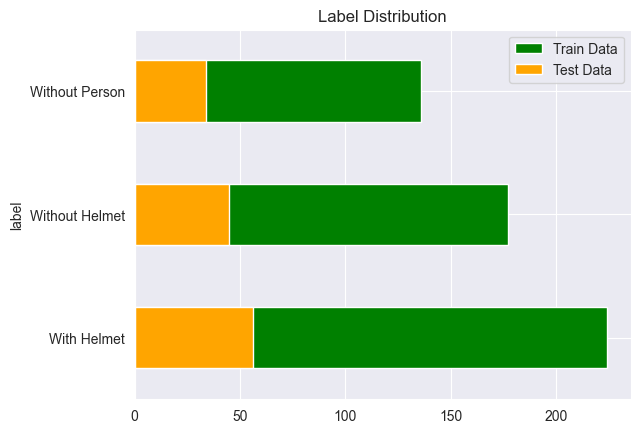

In [11]:
from matplotlib import pyplot as plt

train_df.label.value_counts().sort_index().plot(kind='barh', title='Label Distribution', color='green', label='Train Data')
test_df.label.value_counts().sort_index().plot(kind='barh', title='Label Distribution', color='orange', label='Test Data')
plt.legend();

In [12]:
# Dropping images without a person for now we can add them back if we want to train a more complex model later
train_df = train_df[train_df["label_enum"] != -1]
test_df = test_df[test_df["label_enum"] != -1]
NUM_CLASSES=2

In [13]:
import tensorflow as tf
def convert_to_tf_dataset(df):
    images = []
    labels = []
    for index, row in df.iterrows():
        file_path = row["file_path"]
        label = row["label_enum"]
        if os.path.exists(file_path):
            image = Image.open(file_path).convert("RGB")
            image = image.resize((IMAGE_SIZE, IMAGE_SIZE))
            image = np.array(image).astype('float32')
            images.append(image)
            labels.append(label)
        else:
            print(f"File not found: {file_path}")
    images = np.array(images)
    labels = np.array(labels)
    dataset = tf.data.Dataset.from_tensor_slices((images, labels))
    dataset = dataset.map(lambda x, y: (tf.image.per_image_standardization(x), y)).batch(32)
    return dataset


# Convert train_df and test_df to TensorFlow datasets
train_ds = convert_to_tf_dataset(train_df)
val_ds = convert_to_tf_dataset(test_df)


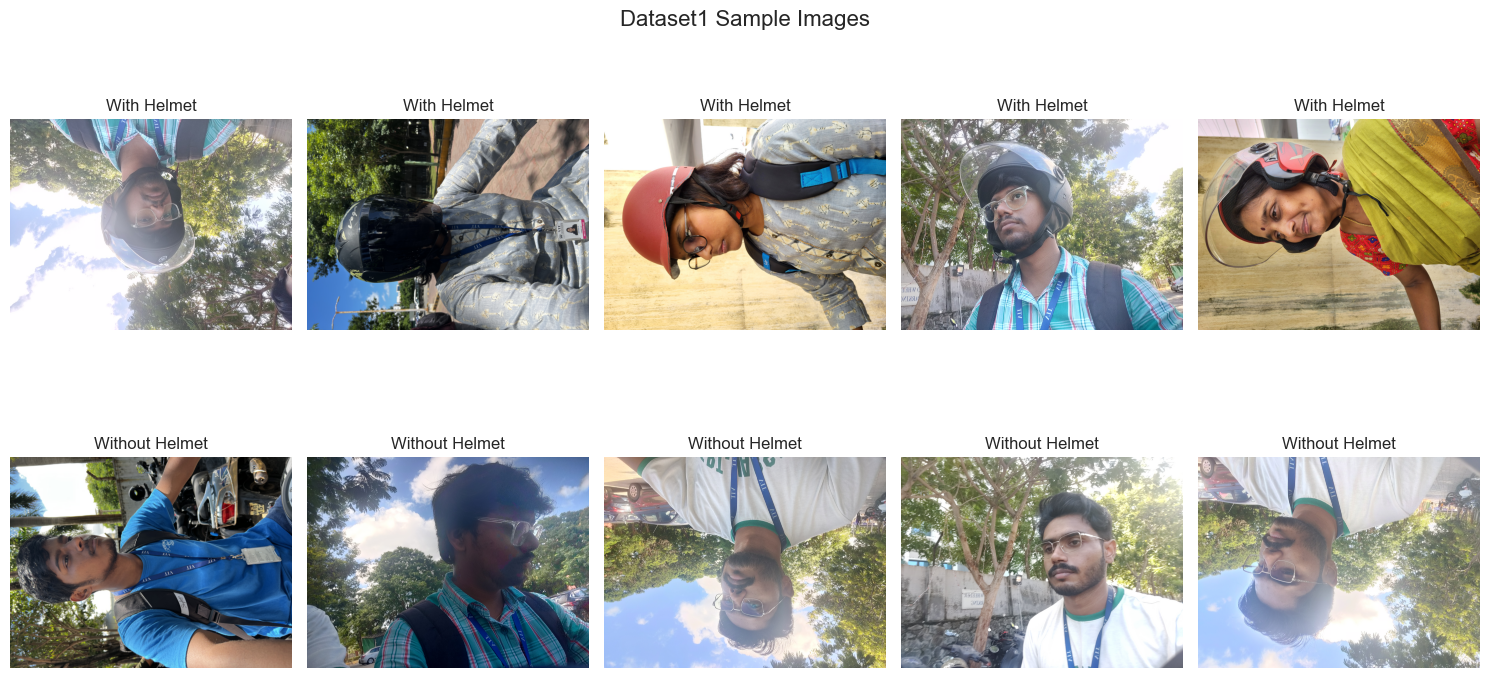

In [14]:
# Display 5 random images from each class
def display_random_images(dataframe, num_images=5, figure_name="random_class_samples.png"):
    # Group by labels
    grouped = dataframe.groupby("label")
    num_classes = len(grouped)

    fig, axes = plt.subplots(
        nrows=num_classes,
        ncols=num_images,
        figsize=(15, 4 * num_classes)
    )
    axes = axes if num_classes > 1 else [axes]  # Handle single row case correctly

    for (label, group), ax_row in zip(grouped, axes):
        sampled_group = group.sample(n=min(num_images, len(group)), random_state=42)
        for i, (_, row) in enumerate(sampled_group.iterrows()):
            img = Image.open(row["file_path"]).convert("RGB")
            ax_row[i].imshow(img)
            ax_row[i].axis("off")
            ax_row[i].set_title(label)

    plt.tight_layout()
    plt.suptitle("Dataset1 Sample Images", fontsize=16)
    plt.savefig("charts/" + figure_name, bbox_inches="tight")
    plt.show()
display_random_images(train_df, num_images=5, figure_name="dataset1_sample_images.png")


## Observations
- This dataset consists of images taken by hand and only contains two test subjects.
- Many of the images in this dataset are upside down or sideways.

In [15]:
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras import Sequential

len(train_ds), len(train_ds)

(13, 13)

In [16]:
def plot_history(history):
  # Plot training & validation accuracy values
  plt.plot(history.history['accuracy'])
  plt.plot(history.history['val_accuracy'])
  plt.title('Model Accuracy')
  plt.ylabel('Accuracy')
  plt.xlabel('Epoch')
  plt.legend(['Train', 'Validation'], loc='upper left')
  plt.show()

In [17]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
import tensorflow as tf
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout

# Load VGG16 base (no top classifier)
vgg_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)   # adjust if needed
)

# Freeze base layers
for layer in vgg_base.layers:
    layer.trainable = False

# Custom classification head
x = vgg_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(1, activation="sigmoid")(x)  # binary classification

# Final model
model_1 = Model(inputs=vgg_base.input, outputs=output)

In [18]:
model_1.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
# Ensure datasets have the correct dimensionality for TensorFlow
train_ds = train_ds.map(lambda x, y: (tf.ensure_shape(x, (None, IMAGE_SIZE, IMAGE_SIZE, IMAGE_CHANNELS)), y))
val_ds = val_ds.map(lambda x, y: (tf.ensure_shape(x, (None, IMAGE_SIZE, IMAGE_SIZE, IMAGE_CHANNELS)), y))

history_1 = model_1.fit(train_ds, validation_data=val_ds, epochs=10)


Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.6883 - loss: 0.6070 - val_accuracy: 0.8713 - val_loss: 0.4387
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.8429 - loss: 0.4122 - val_accuracy: 0.8812 - val_loss: 0.3309
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.9177 - loss: 0.2864 - val_accuracy: 0.9010 - val_loss: 0.2658
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.9501 - loss: 0.2058 - val_accuracy: 0.9406 - val_loss: 0.1941
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.9726 - loss: 0.1446 - val_accuracy: 0.9406 - val_loss: 0.1600
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.9726 - loss: 0.1187 - val_accuracy: 0.9406 - val_loss: 0.1373
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.9875 - loss: 0.0917 - val_accuracy: 0.9406 - val_loss: 0.1268
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.9825 - loss: 0.0946 - val_accuracy: 0.9505 - val_loss:

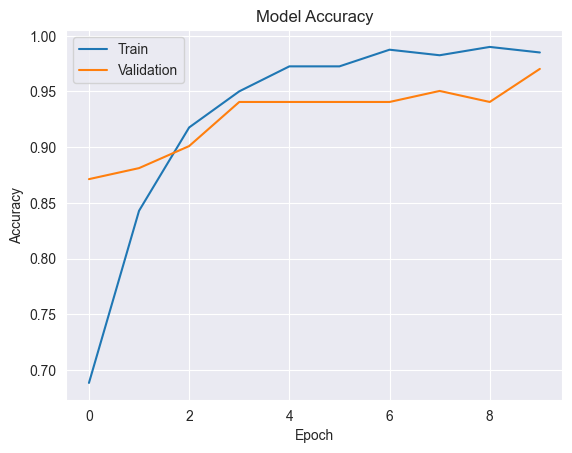

In [19]:
plot_history(history_1)


4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step


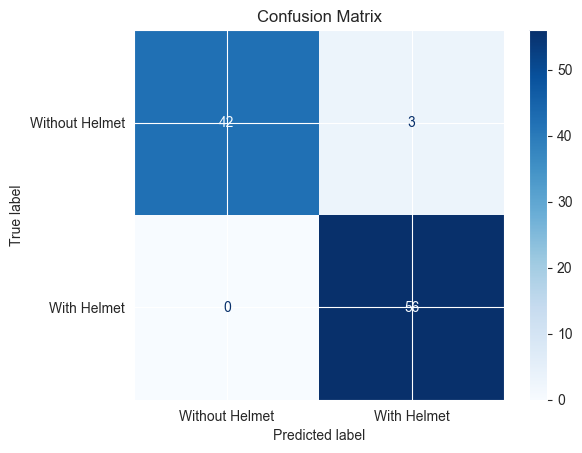

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Assuming validation dataset (val_ds) results and true labels
val_images, val_labels = zip(*[(x.numpy(), y.numpy()) for x, y in val_ds.unbatch()])  # Unbatch validation data
val_images = np.array(val_images)
val_labels = np.array(val_labels)

# Generate predictions
val_predictions = (model_1.predict(val_images) > 0.5).astype(int)

# Create confusion matrix
cm = confusion_matrix(val_labels, val_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Without Helmet", "With Helmet"])

# Display confusion matrix
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()


In [27]:
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score

# Calculate accuracy, precision, and recall
accuracy = accuracy_score(val_labels, val_predictions)
precision = precision_score(val_labels, val_predictions)
recall = recall_score(val_labels, val_predictions)
f1_score = f1_score(val_labels, val_predictions)
# Create a dataframe to display the metrics
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Value": [accuracy, precision, recall, f1_score]
})

metrics_df.to_csv("metrics/model1_metrics.csv")
metrics_df.head()

,Metric,Value
0,Accuracy,0.970297
1,Precision,0.949153
2,Recall,1.000000
3,F1 Score,0.973913


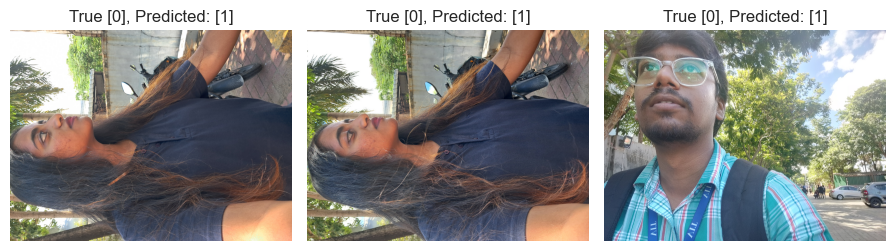

<Figure size 640x480 with 0 Axes>

In [26]:
# Display random incorrectly categorized images
from sklearn.metrics import confusion_matrix
import random

# Confusion matrix to find misclassified images
cm = confusion_matrix(val_labels, val_predictions)
false_categorizations = [
    i for i in range(len(val_labels)) if val_labels[i] !=  val_predictions[i]
]

if false_categorizations:
    sampled_indices = random.sample(false_categorizations, min(5, len(false_categorizations)))
    plt.figure(figsize=(15, 5))
    for idx, random_index in enumerate(sampled_indices):
        misclassified_image_path = test_df.iloc[random_index]["file_path"]
        misclassified_image = np.array(Image.open(misclassified_image_path).convert("RGB"))
        plt.subplot(1, 5, idx + 1)
        plt.imshow(misclassified_image)
        plt.title(f"True [{val_labels[random_index]}], Predicted: {val_predictions[random_index]}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No misclassified 'With Helmet' images found.")
plt.savefig("charts/model1_misclassified_images.png", bbox_inches="tight")

In [22]:
model_1.save("model/HelmNet_Image_Classification.v1.h5")

# Dataset1 Summary
- Two of the misclassified images in the dataset appeared to be duplicates, which makes me worry the dataset has other duplicate images.
- This dataset has an almost equal balance between no helmet samples and helmet samples.
- The images in this dataset only contain two individual riders, which is going to harm the generalizability of the training data.
- Images in this dataset are taken by hand and then resized to 200x200 prior to training.
- Many of the training images were upside down or sideways in this dataset.